# PyPSA-DE Network Analysis


In [48]:
import os
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
import warnings, yaml, pathlib
from matplotlib import cm

# ── Fix GDAL/cartopy data path ──────────────────────────────
import cartopy
gdal_data = os.path.join(os.path.dirname(cartopy.__file__), "data")
if os.path.exists(gdal_data):
    os.environ["GDAL_DATA"] = gdal_data

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
%matplotlib inline

## 0 — Configuration

In [49]:
# ── Networks to compare ────────────────────────────────────────
# Each entry can have its own scenario, cluster count, planning horizon,
# and even its own directory layout / filename pattern — this lets us mix
# our own pypsa-de-thesis runs with externally provided ones (e.g. Ariadne).
ROOT = pathlib.Path(r"C:\repos\pypsa-de")  # path on devcloud: (r"e:\23-06-13_localCode\FiBe\pypsa-de")

# Add/rename entries here to compare different runs.
NETWORKS = {
    "customSSM": dict(
        prefix="test02_custom_map", scenario="KN2045_Mix", clusters=27, year=2030,
    ),  # network 1: custom mixed-resolution (our own thesis run)
    "365Htest": dict(
        prefix="test01_365H_cluster", scenario="KN2045_Mix", clusters=27, year=2030,
    ),  # network 2: 365H reference (our own thesis run)
    "ariadne": dict(
        prefix="ariadne_technologiemix", scenario=None, clusters=49, year=2030,
        filename_pattern="base_s_{clusters}_lvopt__none_{year}.nc",
    ),  # network 3: externally provided Ariadne run (flat layout, no scenario/networks subfolders)
}

def net_file(prefix, clusters, year, scenario=None,
             filename_pattern="base_s_{clusters}__none_{year}.nc"):
    """Path to a solved network.

    Two directory layouts are supported:
      - scenario given:  results/{prefix}/{scenario}/networks/<filename>
        (our own pypsa-de-thesis runs, e.g. test01_365H_cluster, test02_custom_map)
      - scenario=None:   results/{prefix}/<filename>
        (flat layout used by externally provided runs, e.g. the Ariadne project)

    filename_pattern is a format string filled with `clusters` and `year`;
    override it per network to match whatever wildcard string actually
    appears in that run's file names (e.g. "lvopt" for Ariadne networks).
    """
    base_dir = (
        ROOT / "results" / prefix / scenario / "networks"
        if scenario is not None
        else ROOT / "results" / prefix
    )
    return base_dir / filename_pattern.format(clusters=clusters, year=year)


for cfg in NETWORKS.values():
    cfg["file"] = net_file(
        cfg["prefix"], cfg["clusters"], cfg["year"],
        scenario=cfg.get("scenario"),
        filename_pattern=cfg.get("filename_pattern", "base_s_{clusters}__none_{year}.nc"),
    )
    cfg.setdefault("scenario", None)  # keep a scenario key even for flat-layout entries

# Load plotting config for consistent colours (once, shared by all networks)
with open(ROOT / "config" / "plotting.default.yaml") as f:
    plot_cfg = yaml.safe_load(f)["plotting"]
with open(ROOT / "config" / "config.de.yaml") as f:
    de_cfg = yaml.safe_load(f)
tech_colors = {**plot_cfg.get("tech_colors", {}), **de_cfg.get("plotting", {}).get("tech_colors", {})}

for label, cfg in NETWORKS.items():
    print(f"{label:8s}: {cfg['file']}  (exists: {cfg['file'].exists()})")

customSSM: C:\repos\pypsa-de\results\test02_custom_map\KN2045_Mix\networks\base_s_27__none_2030.nc  (exists: True)
365Htest: C:\repos\pypsa-de\results\test01_365H_cluster\KN2045_Mix\networks\base_s_27__none_2030.nc  (exists: True)
ariadne : C:\repos\pypsa-de\results\ariadne_technologiemix\base_s_49_lvopt__none_2030.nc  (exists: True)


#### Choose Network to Analyze

In [60]:
# ── Load networks & choose one to analyse ──────────────────────
# Both networks are loaded once so switching is instant: just change
# CHOICE below and re-run this cell (no need to re-read the .nc files).
nets = {label: pypsa.Network(str(cfg["file"])) for label, cfg in NETWORKS.items()}


def context(choice):
    """All analysis variables derived from the chosen network.

    Call at the top of any analysis cell via
        globals().update(context(CHOICE))
    so the cell is always self-consistent with the current CHOICE and can
    never use a stale `sw` / `de_*` from a previously analysed network
    (which would silently produce wrong or zero results on index mismatch).
    """
    cfg = NETWORKS[choice]
    net = nets[choice]
    de_buses = net.buses.query("country == 'DE' and carrier == 'AC'").index
    de_all_buses = net.buses.query("country == 'DE'").index
    return dict(
        n=net,
        RUN_LABEL=choice,
        SCENARIO=cfg["scenario"],
        CLUSTERS=cfg["clusters"],
        YEAR=cfg["year"],
        de_buses=de_buses,
        de_all_buses=de_all_buses,
        de_gens=net.generators[net.generators.bus.isin(de_buses)].index,
        de_loads=net.loads[net.loads.bus.isin(de_all_buses)].index,
        de_stores=net.stores[net.stores.bus.isin(de_all_buses)].index,
        de_links=net.links[net.links.bus0.isin(de_all_buses)
                           | net.links.bus1.isin(de_all_buses)].index,
        de_sus=net.storage_units[net.storage_units.bus.isin(de_buses)].index,
        sw=net.snapshot_weightings.generators,
    )



def require_fresh(*producers):
    """Fail loudly if a producer cell's data is stale for the current CHOICE.

    Pass (tag_name, cell_name) pairs. Producer cells tag their output at the
    end (e.g. `_prep_choice = CHOICE`); consumer cells call this at the top,
    so a forgotten re-run raises a clear error instead of silently plotting
    zeros or another network's numbers.
    """
    for tag, cell_name in producers:
        if globals().get(tag) != CHOICE:
            raise RuntimeError(
                f"Stale inputs for CHOICE={CHOICE!r}: re-run the '{cell_name}' "
                f"cell first (it was last run for {globals().get(tag)!r})."
            )


CHOICE = "ariadne"          # <- switch analysis target here: "customSSM", "365Htest", or "ariadne"
globals().update(context(CHOICE))

print(f"Loaded {CHOICE} / {SCENARIO} / {YEAR}  —  {len(n.buses)} buses, "
      f"{len(de_buses)} DE AC buses, {len(n.snapshots)} snapshots")

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            ('9', 6),
            ('9', 7)],
           length=352) for attribute mu_neg of Line are not in main components dataframe lines
            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            

Loaded ariadne / None / 2030  —  1343 buses, 30 DE AC buses, 2920 snapshots


## 1 — Network Topology Map
All AC buses, lines, and DC links on a map of Germany.

DataSourceError: C:\repos\pypsa-de\resources\regions_onshore_base_s_49.geojson: No such file or directory

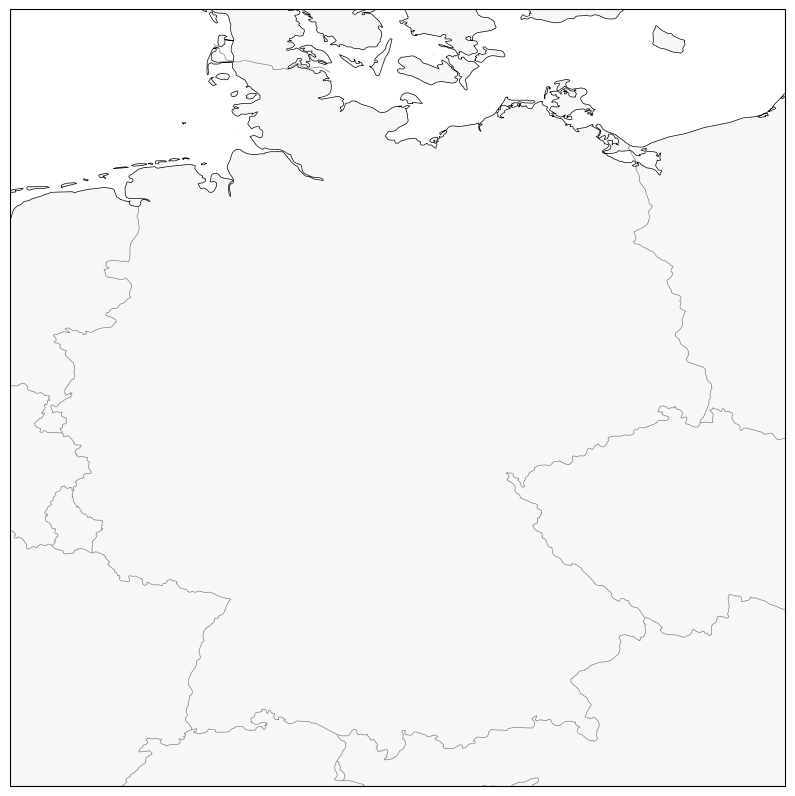

In [61]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)

import geopandas as gpd

proj = ccrs.EqualEarth()
DE_BOUNDS = [5.5, 15.5, 47.0, 55.5]  # lon_min, lon_max, lat_min, lat_max

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# ── DE cluster regions (Voronoi zones) ────────────────────────
regions = gpd.read_file(ROOT / "resources" / f"regions_onshore_base_s_{CLUSTERS}.geojson")
de_regions = regions[regions.name.isin(de_buses)]
# Light transparent fill + solid outline per cluster
cluster_cmap = plt.cm.Pastel2
for i, (_, row) in enumerate(de_regions.iterrows()):
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cluster_cmap(i / max(len(de_regions) - 1, 1)),
        edgecolor="#333333", linewidth=1.0, alpha=0.35, zorder=1,
    )

# AC buses
ac_buses = n.buses[n.buses.carrier == "AC"]
ax.scatter(
    ac_buses.x, ac_buses.y,
    transform=ccrs.PlateCarree(), s=40, zorder=5,
    c=["#d62728" if b in de_buses else "#aaaaaa" for b in ac_buses.index],
    edgecolors="k", linewidths=0.3,
)

# AC lines
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    is_de = ln.bus0 in de_buses or ln.bus1 in de_buses
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(),
        color="#70af1d" if is_de else "#cccccc",
        linewidth=1.0 + 1.5 * (ln.s_nom_opt / n.lines.s_nom_opt.max()) if is_de else 0.5,
        zorder=3,
    )

# DC links (exclude "-reversed" duplicates so each corridor is drawn once)
dc_links = n.links[
    (n.links.carrier == "DC") & ~n.links.index.str.endswith("-reversed")
]
for _, lk in dc_links.iterrows():
    b0, b1 = n.buses.loc[lk.bus0], n.buses.loc[lk.bus1]
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(), color="#8a1caf",
        linewidth=1.2, linestyle="--", zorder=4,
    )

# Legend with proxy artists
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cluster_cmap(0.5), edgecolor="#333333", linewidth=1.0, alpha=0.35, label="Cluster zone (DE)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markeredgecolor="k", markeredgewidth=0.3, markersize=8, label="AC bus (DE)"),
    Line2D([0], [0], color="#70af1d", linewidth=2.0, label="AC line"),
    Line2D([0], [0], color="#8a1caf", linewidth=1.2, linestyle="--", label="DC link"),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title(f"Network topology — {SCENARIO} {YEAR}", fontsize=14)
plt.tight_layout()
plt.show()

_regions_choice = CHOICE  # tag: lets consumer cells detect a stale re-run

## 2 — Battery Storage & Generation / Demand Pie Map
Each German cluster is coloured by installed battery storage capacity.  
Two-sided pie charts show total electricity **generation** (left) vs **demand** (right).

In [62]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)

# ── Prepare per-cluster data ───────────────────────────────────
# Helper: map any bus back to its AC parent via n.buses.location
def to_ac_bus(bus_name):
    if "location" in n.buses.columns and bus_name in n.buses.index:
        loc = n.buses.loc[bus_name, "location"]
        if pd.notna(loc):
            return loc
    return bus_name

# Helper: compute "pre-existing" capacity for a mix of extendable and
# non-extendable (carried-over) components in myopic foresight.
#   - Extendable components: existing capacity = *_nom_min (lower bound)
#   - Non-extendable (brownfield carry-over): existing capacity = *_nom (fixed)
def existing_capacity(df, attr="p"):
    """Return total pre-existing capacity from a components DataFrame."""
    nom = f"{attr}_nom"
    nom_min = f"{attr}_nom_min"
    ext = f"{attr}_nom_extendable"
    extendable = df[ext] if ext in df.columns else pd.Series(False, index=df.index)
    return (
        df.loc[extendable, nom_min].sum()
        + df.loc[~extendable, nom].sum()
    )

# ── Stationary BESS (carrier == "battery", NOT EV/home) ──────
bess_stores = n.stores[
    (n.stores.carrier == "battery")
    & (n.stores.bus.isin(de_all_buses))
].copy()
bess_stores["ac_bus"] = bess_stores.bus.map(to_ac_bus)
bess_cap_per_bus = bess_stores.groupby("ac_bus")["e_nom_opt"].sum() / 1e3  # GWh

# EV batteries (separate, for context)
ev_stores = n.stores[
    (n.stores.carrier == "EV battery")
    & (n.stores.bus.isin(de_all_buses))
]

# Battery charge / discharge power capacity (via links)
batt_ch = n.links[(n.links.carrier == "battery charger") & (n.links.bus0.isin(de_buses))]
batt_dis = n.links[(n.links.carrier == "battery discharger") & (n.links.bus1.isin(de_buses))]
batt_charge_cap = batt_ch["p_nom_opt"].sum() / 1e3   # GW
batt_discharge_cap = batt_dis["p_nom_opt"].sum() / 1e3

# For the map plot: use BESS + home combined for the colour scale
batt_stores_all = n.stores[
    (n.stores.carrier.isin(["battery", "home battery"]))
    & (n.stores.bus.isin(de_all_buses))
].copy()
batt_stores_all["ac_bus"] = batt_stores_all.bus.map(to_ac_bus)
batt_cap_per_bus = batt_stores_all.groupby("ac_bus")["e_nom_opt"].sum() / 1e3  # GWh

# ── Generation per DE AC bus ──────────────────────────────────
# a) Generators (VRE, hydro RoR, etc.)
gen_p = (n.generators_t.p[de_gens].multiply(sw, axis=0)).sum()  # MWh
vre_gen_per_bus = gen_p.groupby(n.generators.loc[de_gens, "bus"]).sum() / 1e6  # TWh

# b) Link-based dispatchable generation injecting into DE AC buses
#    (gas CHPs, CCGTs, H2 fuel cells, etc. — modelled as links, not generators)
_link_gen_excl = {"DC", "battery charger", "battery discharger",
                  "home battery charger", "home battery discharger",
                  "electricity distribution grid"}
link_gen_links = n.links[
    (n.links.bus1.isin(de_buses))
    & ~n.links.carrier.isin(_link_gen_excl)
    & ~n.links.index.str.endswith("-reversed")
]
link_gen_e = -(n.links_t.p1[link_gen_links.index].multiply(sw, axis=0)).sum()  # −p1 = delivery
link_gen_per_bus = link_gen_e.groupby(
    n.links.loc[link_gen_links.index, "bus1"]
).sum() / 1e6  # TWh

# c) Combined total generation per bus
gen_per_bus = vre_gen_per_bus.add(link_gen_per_bus, fill_value=0)

# ── Demand: electricity loads are on low-voltage buses ────────
de_lv_buses = n.buses[(n.buses.country == "DE") & (n.buses.carrier == "low voltage")].index
elec_loads = n.loads[
    (n.loads.bus.isin(de_lv_buses)) & (n.loads.carrier == "electricity")
]
load_p = (n.loads_t.p_set[elec_loads.index].multiply(sw, axis=0)).sum()
# Map LV bus → AC bus for spatial aggregation
elec_loads_ac = elec_loads.bus.map(to_ac_bus)
load_per_bus = load_p.groupby(elec_loads_ac).sum() / 1e6  # TWh

# ── Home batteries (on low-voltage bus) ───────────────────────
home_batt_stores = n.stores[
    (n.stores.carrier == "home battery")
    & (n.stores.bus.isin(de_all_buses))
]
home_batt_ch = n.links[(n.links.carrier == "home battery charger") & (n.links.bus0.isin(de_lv_buses))]
home_batt_dis = n.links[(n.links.carrier == "home battery discharger") & (n.links.bus1.isin(de_lv_buses))]

# ── Net electricity consumption per bus (incl. sector coupling) ────
# Sum all withdrawals from DE AC buses: links + loads.
# Includes heat pumps, electrolysis, EV charging (via LV distribution), etc.
# Excludes round-trip storage (BESS, home battery, PHS) whose energy returns to the grid.

# a) Links withdrawing from AC buses (bus0 on AC, excl. DC & reversed)
# Exclude round-trip storage chargers (energy returns to grid via discharger)
round_trip_carriers = {"battery charger", "home battery charger"}
ac_consuming_links = n.links[
    (n.links.bus0.isin(de_buses))
    & (n.links.carrier != "DC")
    & ~n.links.carrier.isin(round_trip_carriers)
    & ~n.links.index.str.endswith("-reversed")
]
link_withdrawal = (
    n.links_t.p0[ac_consuming_links.index]
    .clip(lower=0).multiply(sw, axis=0)
).sum()
link_withdrawal_per_bus = link_withdrawal.groupby(
    n.links.loc[ac_consuming_links.index, "bus0"]
).sum() / 1e6  # TWh

# b) Loads directly on AC buses (if any)
ac_direct_loads = n.loads[n.loads.bus.isin(de_buses)]
if len(ac_direct_loads):
    ac_load_e = (n.loads_t.p_set[ac_direct_loads.index].multiply(sw, axis=0)).sum()
    ac_load_per_bus = ac_load_e.groupby(n.loads.loc[ac_direct_loads.index, "bus"]).sum() / 1e6
# c) Storage-unit charging (PHS) excluded — round-trip storage returns to grid

# Combine into net electricity consumption per AC bus
# (excl. BESS & PHS charging which discharge back to grid;
#  incl. EV charging via LV distribution, heat pumps, electrolysis, etc.)
total_elec_per_bus = link_withdrawal_per_bus.copy()
if len(ac_direct_loads):
    total_elec_per_bus = total_elec_per_bus.add(ac_load_per_bus, fill_value=0)

# ── Summary ──────────────────────────────────────────────────
# NOTE: "Existing" = pre-existing capacity before this horizon's optimization.
#   - For extendable components: read from *_nom_min (optimizer lower bound)
#   - For non-extendable (brownfield carry-over): read from *_nom (fixed capacity)
# This is handled by the existing_capacity() helper defined above.
W = 63

def _p(s):
    print(f"║{s:<{W}}║")

def _hdr():
    _p(f"  {'':24s}{'Existing':>10s}  {'Expansion':>10s}  {'Total':>10s} ")

def _row(label, exist, total):
    expan = total - exist
    _p(f"    {label:22s}{exist:10.3f}  {expan:10.3f}  {total:10.3f} ")

print("╔" + "═" * W + "╗")
print(f"║{f'Battery Storage Summary — DE {YEAR}':^{W}}║")
print("╠" + "═" * W + "╣")

_p(" 1) Grid-scale BESS (AC bus)")
_hdr()
_row("Energy [GWh]",   existing_capacity(bess_stores, "e")/1e3, bess_stores.e_nom_opt.sum()/1e3)
_row("Charge [GW]",    existing_capacity(batt_ch, "p")/1e3,     batt_charge_cap)
_row("Discharge [GW]", existing_capacity(batt_dis, "p")/1e3,    batt_discharge_cap)
_p("")
_p(" 2) Home batteries (LV bus)")
_hdr()
_row("Energy [GWh]",   existing_capacity(home_batt_stores, "e")/1e3, home_batt_stores.e_nom_opt.sum()/1e3)
_row("Charge [GW]",    existing_capacity(home_batt_ch, "p")/1e3,     home_batt_ch.p_nom_opt.sum()/1e3)
_row("Discharge [GW]", existing_capacity(home_batt_dis, "p")/1e3,    home_batt_dis.p_nom_opt.sum()/1e3)
_p("")
_p(" 3) EV batteries (LV bus, exogenous)")
_hdr()
_row("Energy [GWh]",   ev_stores.e_nom.sum()/1e3,          ev_stores.e_nom_opt.sum()/1e3)

print("╠" + "═" * W + "╣")
_p(f"  VRE + hydro gen.:     {vre_gen_per_bus.sum():>30.1f} TWh")
_p(f"  Dispatchable gen.:    {link_gen_per_bus.sum():>30.1f} TWh")
_p(f"    (CHPs, CCGTs, H2 turbines, etc.)")
_p(f"  Total DE generation:  {gen_per_bus.sum():>30.1f} TWh")
_p(f"  Direct elec demand:   {load_per_bus.sum():>30.1f} TWh")
_p(f"  Net elec consump.:    {total_elec_per_bus.sum():>30.1f} TWh")
_p(f"    (excl. BESS/PHS round-trip; incl. HP, H2, EV, etc.)")
print("╚" + "═" * W + "╝")

_prep_choice = CHOICE  # tag: lets consumer cells detect a stale re-run

╔═══════════════════════════════════════════════════════════════╗
║               Battery Storage Summary — DE 2030               ║
╠═══════════════════════════════════════════════════════════════╣
║ 1) Grid-scale BESS (AC bus)                                   ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]               0.000      33.938      33.938   ║
║    Charge [GW]                0.000       3.849       3.849   ║
║    Discharge [GW]             0.000       3.928       3.928   ║
║                                                               ║
║ 2) Home batteries (LV bus)                                    ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]               0.144       0.004       0.148   ║
║    Charge [GW]                0.040       0.003       0.043   ║
║    Discharge [GW]             0.041       0.003       0.044   ║
║                                                               ║
║ 3) EV ba

In [63]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)
require_fresh(("_prep_choice", "Prepare per-cluster data"),
              ("_regions_choice", "Network Topology Map"))

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

# ── Fill DE cluster zones with BESS heatmap ───────────────────
batt_vals = batt_cap_per_bus.reindex(de_buses, fill_value=0)  #dont include EV batteries, see previous cell
vmax = max(batt_vals.max(), 0.01)
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.YlOrRd

for _, row in de_regions.iterrows():
    bus = row["name"]
    val = batt_vals.get(bus, 0)
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap(norm(val)),
        edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label("Battery storage [GWh]")

# ── Two-sided pie charts (generation left, net consumption right) ──
PIE_SCALE = 0.75  # visual radius scaling factor
# demand_per_bus = load_per_bus          # direct electricity demand only
demand_per_bus = total_elec_per_bus      # net (excl. BESS/PHS round-trip)
max_val = max(gen_per_bus.max(), demand_per_bus.max(), 0.01)

for bus in de_buses:
    bx, by = proj.transform_point(
        ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree()
    )
    g = gen_per_bus.get(bus, 0)
    d = demand_per_bus.get(bus, 0)
    r = PIE_SCALE * np.sqrt(max(g, d) / max_val) * 1e5  # radius in map units
    if r < 1e3:
        continue
    # Left half = generation (green), right half = net consumption (orange)
    w_gen  = Wedge((bx, by), r, 90, 270, facecolor="#4daf4a", edgecolor="k", linewidth=0.3, alpha=0.75)
    w_load = Wedge((bx, by), r * np.sqrt(d / max(g, 1e-9)), 270, 90,
                   facecolor="#ff7f00", edgecolor="k", linewidth=0.3, alpha=0.75)
    ax.add_patch(w_gen)
    ax.add_patch(w_load)

# Legend proxy
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4daf4a", markersize=10, label="Generation (left)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f00", markersize=10, label="Net elec. consumption (right)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title(f"Battery storage & generation/demand — {SCENARIO} {YEAR}", fontsize=13)
plt.tight_layout()
plt.show()

RuntimeError: Stale inputs for CHOICE='ariadne': re-run the 'Network Topology Map' cell first (it was last run for 'customSSM').

## 3 — Mean Electricity Price Map
Mean marginal price (€/MWh) at each German AC bus, written on the map.

In [64]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)
require_fresh(("_prep_choice", "Prepare per-cluster data"),
              ("_regions_choice", "Network Topology Map"))

# Weighted-average marginal price per bus (weighted by snapshot hours)
mean_price = (n.buses_t.marginal_price[de_buses].multiply(sw, axis=0)).sum() / sw.sum()

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

# ── Fill DE cluster zones with price heatmap ──────────────────
norm_p = mcolors.Normalize(vmin=mean_price.min(), vmax=mean_price.max())
cmap_p = plt.cm.RdYlGn_r

for _, row in de_regions.iterrows():
    bus = row["name"]
    val = mean_price.get(bus, mean_price.mean())
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap_p(norm_p(val)),
        edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1,
    )

# Colorbar via ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=norm_p)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label("Mean electricity price [€/MWh]")

# ── Annotate each cluster with its price ──────────────────────
for bus in de_buses:
    bx, by = proj.transform_point(
        ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree()
    )
    ax.annotate(
        f"{mean_price[bus]:.0f}",
        xy=(bx, by), fontsize=9, fontweight="bold",
        ha="center", va="center",
        color="k",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
        zorder=5,
    )

ax.set_title(f"Mean electricity price per cluster — {SCENARIO} {YEAR}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nDE load-weighted avg price: "
      f"{(mean_price * load_per_bus.reindex(de_buses, fill_value=0)).sum() / load_per_bus.sum():.1f} €/MWh")

RuntimeError: Stale inputs for CHOICE='ariadne': re-run the 'Network Topology Map' cell first (it was last run for 'customSSM').

## 4 — Installed Capacity Pie Chart (Germany)
Pie chart of optimal installed generation & storage capacities in GW.

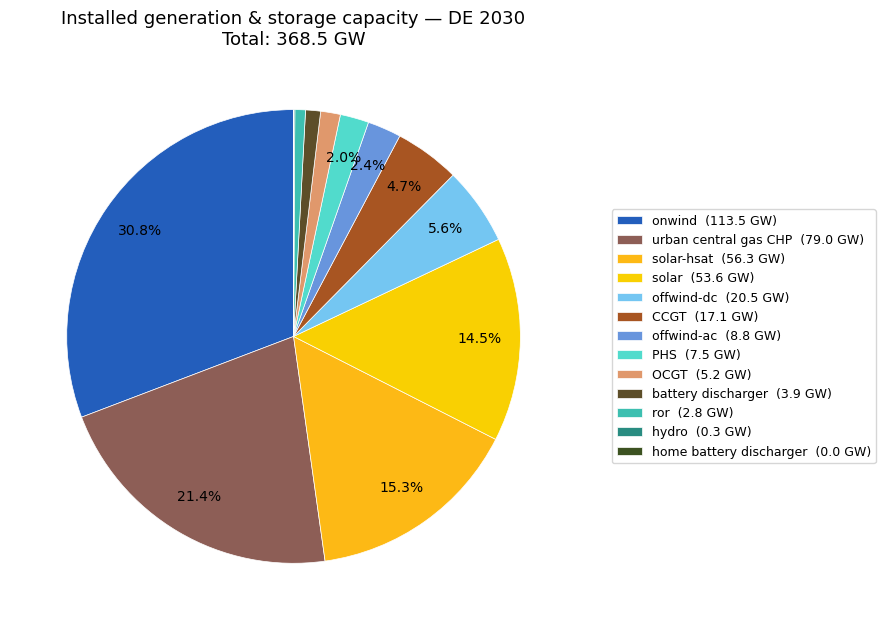

In [65]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)

# ── Collect optimal capacities (MW → GW) ──────────────────────
cap = {}

# Generators
g = n.generators[n.generators.bus.isin(de_buses)]
cap_gen = g.groupby("carrier")["p_nom_opt"].sum() / 1e3
cap.update(cap_gen.to_dict())

# Storage units (PHS, hydro)
su = n.storage_units[n.storage_units.bus.isin(de_buses)]
cap_su = su.groupby("carrier")["p_nom_opt"].sum() / 1e3
cap.update(cap_su.to_dict())

# Links acting as generators towards AC buses (battery discharger, H2 Fuel Cell, etc.)
disp_carriers = ["battery discharger", "home battery discharger",
                 "H2 Fuel Cell", "H2 OCGT", "H2 CCGT",
                 "H2 retrofit OCGT", "H2 retrofit CCGT",
                 "urban central gas CHP", "urban central gas CHP CC",
                 "OCGT", "CCGT"]
for c in disp_carriers:
    lk = n.links[(n.links.carrier == c) & (n.links.bus0.isin(de_all_buses) | n.links.bus1.isin(de_all_buses))]
    if not lk.empty:
        cap[c] = lk["p_nom_opt"].sum() / 1e3

cap_s = pd.Series(cap).sort_values(ascending=False)
cap_s = cap_s[cap_s > 0.01]  # drop negligible

# Assign colours
colors = [tech_colors.get(c, "#cccccc") for c in cap_s.index]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    cap_s.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=colors, startangle=90, pctdistance=0.82,
    wedgeprops=dict(edgecolor="w", linewidth=0.5),
)
ax.legend(
    wedges, [f"{c}  ({v:.1f} GW)" for c, v in cap_s.items()],
    loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9,
)
ax.set_title(f"Installed generation & storage capacity — DE {YEAR}\nTotal: {cap_s.sum():.1f} GW", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Generation, Demand & Storage Dispatch
Stacked area plot of electricity generation, demand, and battery charge/discharge.  
Set `T_START` / `T_END` to zoom into a specific period (e.g. a winter week).

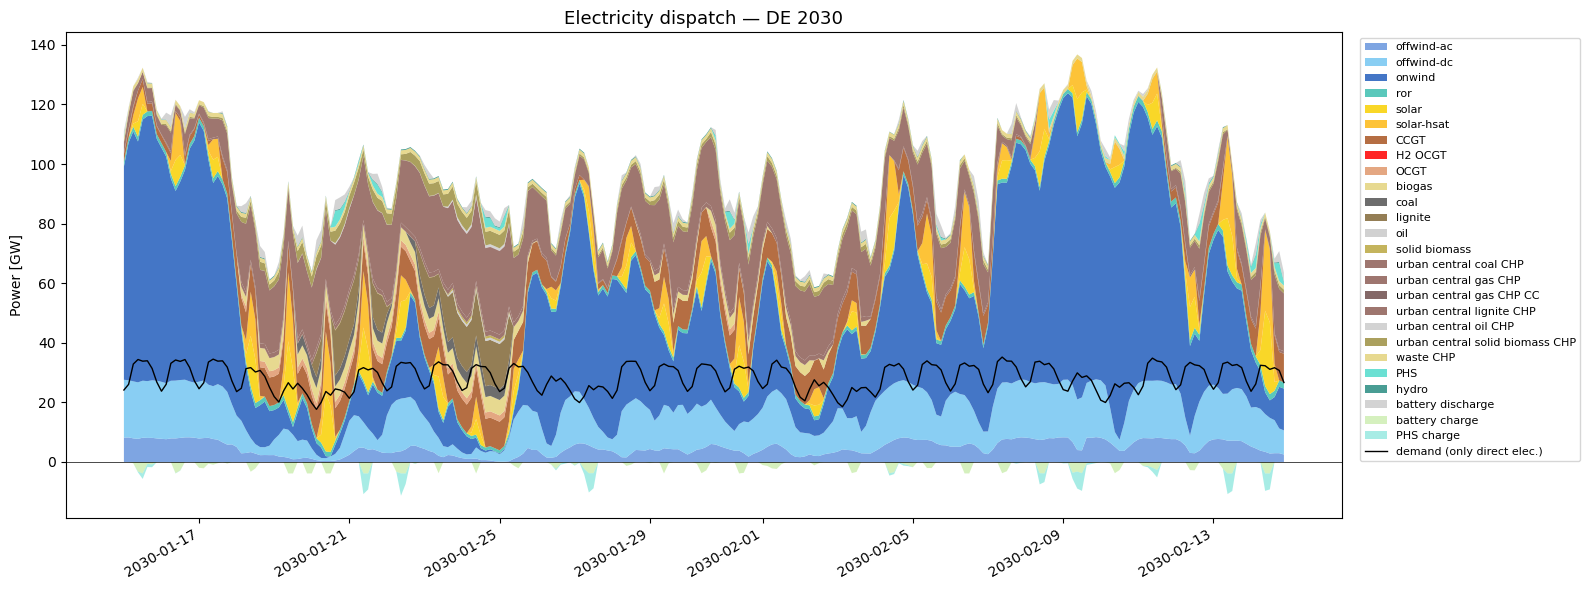

In [66]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)
require_fresh(("_prep_choice", "Prepare per-cluster data"))

# ── Time window (set to None for full year) ───────────────────
T_START = "2030-01-15"#None   # e.g. "2013-01-15"
T_END   = "2030-02-15"#None   # e.g. "2013-01-29"

ts = n.snapshots
# Shift weather-year timestamps to the model planning horizon for display
year_offset = pd.DateOffset(years=YEAR - ts[0].year)
ts_display = ts + year_offset

if T_START and T_END:
    # Accept dates in either the model year or the weather year
    mask = (ts_display >= T_START) & (ts_display < T_END)
    ts_sel = ts[mask]
    ts_sel_display = ts_display[mask]
else:
    ts_sel = ts
    ts_sel_display = ts_display

# ── Generation by carrier ─────────────────────────────────────
gen_ts = n.generators_t.p[de_gens].loc[ts_sel]
gen_by_carrier = gen_ts.T.groupby(n.generators.loc[de_gens, "carrier"]).sum().T / 1e3  # GW

# Storage-unit dispatch (PHS, hydro)
su_ts = n.storage_units_t.p[de_sus].loc[ts_sel]
su_by_carrier = su_ts.T.groupby(n.storage_units.loc[de_sus, "carrier"]).sum().T / 1e3

# Battery charge / discharge via links
batt_ch_links = n.links[(n.links.carrier == "battery charger") & (n.links.bus0.isin(de_buses))]
batt_dis_links = n.links[(n.links.carrier == "battery discharger") & (n.links.bus1.isin(de_buses))]
batt_charge = n.links_t.p0[batt_ch_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_ch_links) else pd.Series(0, index=ts_sel)
batt_discharge = -n.links_t.p1[batt_dis_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_dis_links) else pd.Series(0, index=ts_sel)

# Link-based dispatchable generation (CHPs, CCGTs, H2 turbines, etc.)
# Uses the same link_gen_links selection from cell 9
disp_gen_ts = -n.links_t.p1[link_gen_links.index].loc[ts_sel]  # −p1 = delivery to AC bus
disp_by_carrier = disp_gen_ts.T.groupby(
    n.links.loc[link_gen_links.index, "carrier"]
).sum().T / 1e3  # GW
# Drop carriers with negligible output
disp_by_carrier = disp_by_carrier.loc[:, disp_by_carrier.sum() > 0.01]

# Total electricity demand
elec_load_ts = n.loads_t.p_set[elec_loads.index].loc[ts_sel].sum(axis=1) / 1e3  # GW

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Stack generation + discharge (positive)
pos_data = gen_by_carrier.copy()
for c in disp_by_carrier.columns:
    pos_data[c] = disp_by_carrier[c]
for c in su_by_carrier.columns:
    pos_data[c] = su_by_carrier[c].clip(lower=0)
pos_data["battery discharge"] = batt_discharge
pos_colors = [tech_colors.get(c, "#cccccc") for c in pos_data.columns]
ax.stackplot(ts_sel_display, pos_data.values.T, labels=pos_data.columns, colors=pos_colors, alpha=0.85)

# Negative: battery charging + pumped-hydro charging
neg = pd.DataFrame(index=ts_sel)
neg["battery charge"] = -batt_charge
for c in su_by_carrier.columns:
    neg_vals = su_by_carrier[c].clip(upper=0)
    if (neg_vals < 0).any():
        neg[c + " charge"] = neg_vals
neg_colors = [tech_colors.get(c.replace(" charge", ""), "#999999") for c in neg.columns]
ax.stackplot(ts_sel_display, neg.values.T, colors=neg_colors, alpha=0.5, labels=neg.columns)

# Demand line
ax.plot(ts_sel_display, elec_load_ts.values, color="k", linewidth=1.0, label="demand (only direct elec.)")

ax.set_ylabel("Power [GW]")
ax.set_title(f"Electricity dispatch — DE {YEAR}", fontsize=13)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, ncol=1)
ax.axhline(0, color="k", linewidth=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6 — Electricity Price Time Series DataFrame
Per-cluster marginal prices and their mean across all DE clusters.

In [67]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)

# Build price DataFrame
prices_df = n.buses_t.marginal_price[de_buses].copy()
prices_df.columns = [c.replace(" ", "_") for c in prices_df.columns]
prices_df["DE_mean"] = prices_df.mean(axis=1)

# Basic statistics
print(prices_df.describe().round(1))
prices_df.head(40)

        DE0_0   DE0_1  DE0_10  DE0_11  DE0_12  DE0_13  DE0_14  DE0_15  DE0_16  \
count  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0   
mean     90.2    91.1    91.3    86.4    92.1    92.4    89.2    81.7    87.0   
std      86.5    82.7    81.2    81.5    85.1    85.0    79.4    84.0    80.0   
min       0.0    -0.2    -0.0     0.0     0.0     0.0    -1.3     0.0    -0.4   
25%      55.1    58.6    58.9    53.7    59.4    59.4    58.6    49.0    54.3   
50%      93.0    97.7    98.9    90.2    97.0    96.9    98.7    82.7    90.4   
75%     119.9   116.5   115.8   112.2   119.5   118.9   112.9   108.4   114.6   
max    1405.1  1331.7  1317.5  1312.3  1378.4  1396.4  1271.0  1381.9  1275.2   

       DE0_17  DE0_18  DE0_19   DE0_2  DE0_20  DE0_21  DE0_22  DE0_23  DE0_24  \
count  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0   
mean     87.0    91.7    88.0    83.3    94.4    91.3    84.9    79.4    89.8   
std      87.4    83.1    85

,DE0_0,DE0_1,DE0_10,DE0_11,DE0_12,DE0_13,DE0_14,DE0_15,DE0_16,DE0_17,DE0_18,DE0_19,DE0_2,DE0_20,DE0_21,DE0_22,DE0_23,DE0_24,DE0_25,DE0_26,DE0_27,DE0_28,DE0_29,DE0_3,DE0_4,DE0_5,DE0_6,DE0_7,DE0_8,DE0_9,DE_mean
snapshot,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,73.357569,84.856987,96.553071,60.676499,116.775005,95.370087,93.283140,35.630215,65.581232,39.099082,83.191035,60.365924,52.266065,127.540180,101.108042,50.191672,21.405380,74.619008,106.552587,53.566633,97.401832,49.659532,75.265160,87.433933,60.719775,48.776723,107.698415,93.238913,53.385183,104.260058,75.660965
2019-01-01 03:00:00,63.798615,81.393830,95.905766,48.103062,117.155223,95.369954,93.101295,20.585052,51.631765,24.049352,80.355797,48.611611,38.529123,128.560417,100.657374,22.719253,18.020196,66.751698,105.555387,37.499073,96.614443,41.102433,67.759495,84.277495,46.562415,11.209205,108.606563,92.570330,41.174936,104.260188,67.749712
2019-01-01 06:00:00,48.481125,76.316551,90.512757,24.071538,112.239818,95.370122,86.766771,7.853180,0.045769,0.025906,77.603457,20.692190,16.611036,126.811430,96.087287,10.607256,6.615241,56.727670,101.919346,11.317456,91.547313,12.040660,69.884012,78.525938,9.522344,3.015048,102.119100,86.410681,17.373986,100.778335,54.596444
2019-01-01 09:00:00,42.943034,52.290573,72.533198,15.449027,94.196910,64.886828,67.176027,2.409148,0.044888,0.051542,53.712401,18.565154,9.492043,110.683064,85.800250,7.292251,0.045919,38.255108,82.775961,5.617847,74.883803,0.657284,48.154611,48.245276,5.650526,0.046513,88.107788,66.729040,11.924079,83.908512,41.750954
2019-01-01 12:00:00,41.357476,52.307510,72.544917,15.483094,92.502008,64.886802,67.154566,2.636951,0.044784,0.045020,53.712398,18.417502,9.572279,109.158869,85.870752,7.112618,0.484402,38.255050,81.955900,5.652145,74.910920,0.617609,48.152307,48.245014,5.669113,0.045895,88.107793,66.719205,11.923901,84.032479,41.585976
2019-01-01 15:00:00,41.007428,52.480372,73.032587,15.692425,92.213391,64.886874,67.212400,3.969694,0.045000,0.025819,53.712354,17.714925,10.048603,108.041353,86.361970,6.864834,3.039671,38.255062,81.454919,5.862097,75.604519,0.046358,48.152337,48.172752,5.783537,0.046034,88.108235,66.882207,11.955153,84.335924,41.700295
2019-01-01 18:00:00,41.013693,52.469751,73.039325,15.684442,92.262705,64.886845,67.219126,3.963732,0.044939,0.025812,53.712256,17.647807,10.042385,108.041103,86.361946,6.876500,3.035267,38.255080,81.457152,5.858533,75.611887,0.046464,48.152106,48.174273,5.780417,0.046074,88.174241,66.886788,11.924399,84.334807,41.700995
2019-01-01 21:00:00,41.006131,52.470520,73.032456,15.707498,92.208775,64.886840,67.214976,3.974496,0.045017,0.025819,53.712379,17.717271,10.059747,108.041125,86.361800,6.864221,3.044056,38.255359,81.454456,5.872255,75.603627,0.046426,48.152073,48.168516,5.790364,0.048354,88.108396,66.882612,11.960998,84.335012,41.701719
2019-01-02 00:00:00,41.001735,52.497486,73.030919,15.674664,92.186702,64.886858,67.201880,3.893640,0.044956,0.025812,53.712524,17.723056,10.017205,108.041121,86.361927,6.853984,2.827460,38.255557,81.461568,5.844780,75.606120,0.046360,48.151837,48.211025,5.773976,0.046197,88.107796,66.876899,11.935666,84.432090,41.691060


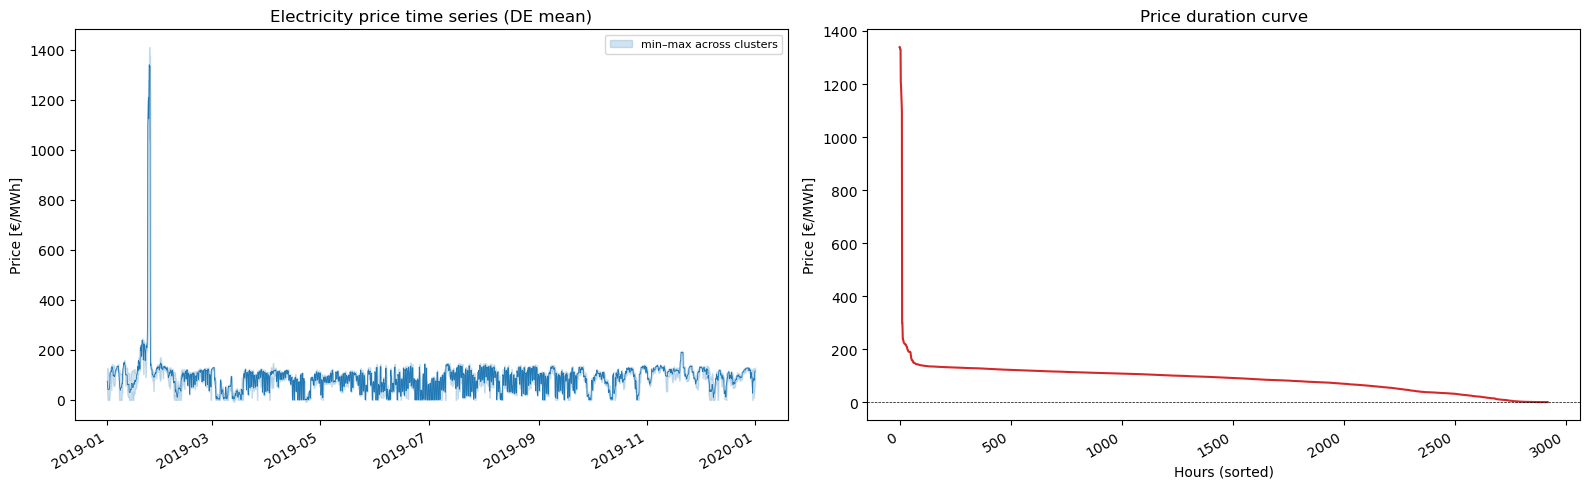

In [68]:
# ── Price duration curve + time series ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series
axes[0].plot(prices_df.index, prices_df["DE_mean"], linewidth=0.6, color="#1f77b4")
axes[0].fill_between(
    prices_df.index,
    prices_df.drop(columns="DE_mean").min(axis=1),
    prices_df.drop(columns="DE_mean").max(axis=1),
    alpha=0.2, color="#1f77b4", label="min–max across clusters",
)
axes[0].set_ylabel("Price [€/MWh]")
axes[0].set_title("Electricity price time series (DE mean)")
axes[0].legend(fontsize=8)
fig.autofmt_xdate()

# Duration curve
sorted_prices = np.sort(prices_df["DE_mean"].values)[::-1]
axes[1].plot(range(len(sorted_prices)), sorted_prices, color="#d62728")
axes[1].set_xlabel("Hours (sorted)")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].set_title("Price duration curve")
axes[1].axhline(0, color="k", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

# XX Additional Diagnostics

In [59]:
globals().update(context(CHOICE))  # self-consistent with current CHOICE (no stale sw/de_*)

# ── Electricity-sector bus hierarchy diagnostic ───────────────
# Pick one DE AC bus to trace all connected components
ref_bus = de_buses[0]
ref_loc = ref_bus  # the "location" field on sub-buses points back here

print(f"═══ Reference cluster: {ref_bus} ═══\n")

# 1) Find all buses at this location
cluster_buses = n.buses[n.buses.location == ref_loc].sort_values("carrier")
print("── All buses at this location ──")
for _, b in cluster_buses.iterrows():
    print(f"  {b.name:40s}  carrier: {b.carrier}")

# 2) Lines (AC ↔ AC only)
lines_here = n.lines[(n.lines.bus0 == ref_bus) | (n.lines.bus1 == ref_bus)]
print(f"\n── Lines (AC transmission) ── [{len(lines_here)}]")
for _, ln in lines_here.iterrows():
    other = ln.bus1 if ln.bus0 == ref_bus else ln.bus0
    print(f"  {ref_bus} ↔ {other}  s_nom_opt={ln.s_nom_opt:.0f} MW")

# 3) Generators
gens_here = n.generators[n.generators.bus.isin(cluster_buses.index)]
print(f"\n── Generators ── [{len(gens_here)}]")
for carrier, grp in gens_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 4) Loads
loads_here = n.loads[n.loads.bus.isin(cluster_buses.index)]
print(f"\n── Loads ── [{len(loads_here)}]")
for _, ld in loads_here.iterrows():
    bus_carrier = n.buses.loc[ld.bus, "carrier"]
    print(f"  {ld.carrier:35s} ← {bus_carrier:15s} bus")

# 5) Storage units
sus_here = n.storage_units[n.storage_units.bus.isin(cluster_buses.index)]
print(f"\n── Storage units ── [{len(sus_here)}]")
for carrier, grp in sus_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 6) Stores
stores_here = n.stores[n.stores.bus.isin(cluster_buses.index)]
print(f"\n── Stores ── [{len(stores_here)}]")
for carrier, grp in stores_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   e_nom_opt={grp.e_nom_opt.sum():.0f} MWh")

# 7) Links — the key connectivity layer
links_here = n.links[
    n.links.bus0.isin(cluster_buses.index) |
    n.links.bus1.isin(cluster_buses.index)
]
# Filter to links where at least one end is in the electricity domain
elec_carriers = {"AC", "low voltage", "battery", "home battery", "EV battery"}
elec_links = links_here[
    links_here.bus0.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers) |
    links_here.bus1.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers)
]
print(f"\n── Links (electricity-related) ── [{len(elec_links)}]")
for carrier, grp in elec_links.groupby("carrier"):
    row = grp.iloc[0]
    b0c = n.buses.loc[row.bus0, "carrier"] if row.bus0 in n.buses.index else "?"
    b1c = n.buses.loc[row.bus1, "carrier"] if row.bus1 in n.buses.index else "?"
    # Check for bus2, bus3 (multi-output links like CHP)
    extra = ""
    if hasattr(row, "bus2") and pd.notna(row.get("bus2", None)) and row.bus2 in n.buses.index:
        extra += f" → bus2: {n.buses.loc[row.bus2, 'carrier']}"
    print(f"  {carrier:40s}  {b0c:15s} → {b1c:15s}  p_nom_opt={grp.p_nom_opt.sum():8.0f} MW{extra}")

═══ Reference cluster: DE2 0 ═══

── All buses at this location ──
  DE2 0                                     carrier: AC
  DE2 0 EV battery                          carrier: EV battery
  DE2 0 H2                                  carrier: H2
  DE2 0 agriculture machinery oil           carrier: agriculture machinery oil
  DE2 0 battery                             carrier: battery
  DE2 0 biogas                              carrier: biogas
  DE2 0 co2 sequestered                     carrier: co2 sequestered
  DE2 0 co2 stored                          carrier: co2 stored
  DE2 0 coal for industry                   carrier: coal for industry
  DE2 0 gas for industry                    carrier: gas for industry
  DE2 0 home battery                        carrier: home battery
  DE2 0 kerosene for aviation               carrier: kerosene for aviation
  DE2 0 land transport oil                  carrier: land transport oil
  DE2 0 low voltage                         carrier: low voltage
  DE2